In [1]:
from sklearn.datasets import load_linnerud
import pandas as pd

In [2]:
linnerud = load_linnerud()

In [3]:
df_exercises = pd.DataFrame(linnerud.data, columns=linnerud.feature_names)

In [4]:
df_stats = pd.DataFrame(linnerud.target, columns=linnerud.target_names)

In [5]:
print("Exercise Data (Features):")
print(df_exercises.head())
print("\nBody Stats (Targets):")
print(df_stats.head())

Exercise Data (Features):
   Chins  Situps  Jumps
0    5.0   162.0   60.0
1    2.0   110.0   60.0
2   12.0   101.0  101.0
3   12.0   105.0   37.0
4   13.0   155.0   58.0

Body Stats (Targets):
   Weight  Waist  Pulse
0   191.0   36.0   50.0
1   189.0   37.0   52.0
2   193.0   38.0   58.0
3   162.0   35.0   62.0
4   189.0   35.0   46.0


In [6]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    linnerud.data, linnerud.target, test_size=0.2, random_state=42
)

In [8]:
model = MultiOutputRegressor(GradientBoostingRegressor(random_state=42))

In [9]:
model.fit(X_train, y_train)

MultiOutputRegressor(estimator=GradientBoostingRegressor(random_state=42))

In [10]:
import numpy as np

In [11]:
predictions = model.predict(X_test)

In [12]:
for i, name in enumerate(linnerud.target_names):
    mse = mean_squared_error(y_test[:, i], predictions[:, i])
    rmse = np.sqrt(mse)
    print(f"{name} Prediction Error (RMSE): {rmse:.2f}")

Weight Prediction Error (RMSE): 28.37
Waist Prediction Error (RMSE): 2.83
Pulse Prediction Error (RMSE): 5.95


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
full_df = pd.concat([df_exercises, df_stats], axis=1)

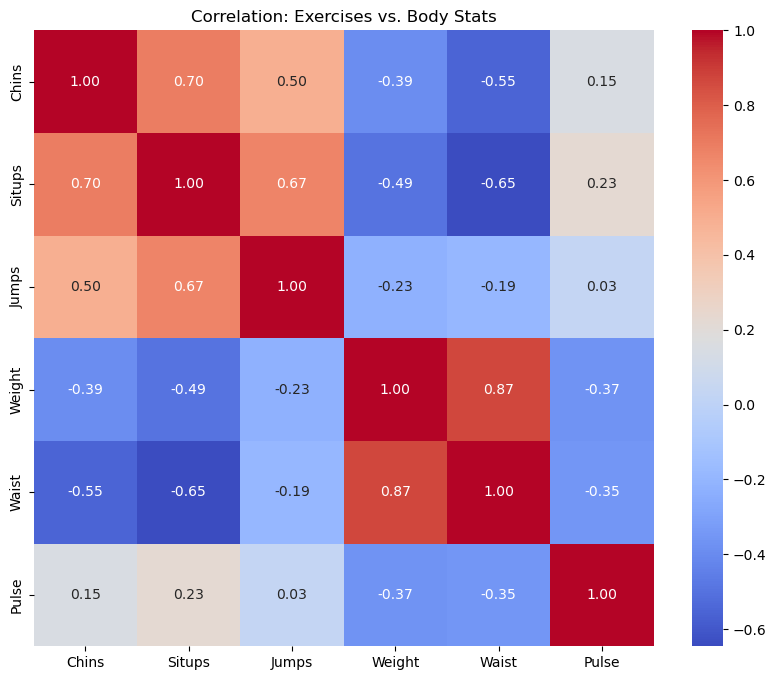

In [15]:
plt.figure(figsize=(10, 8))
correlation_matrix = full_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Exercises vs. Body Stats")
plt.show()

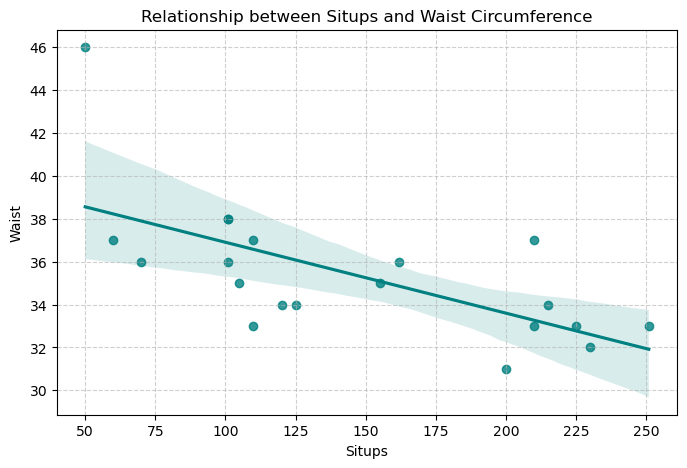

In [16]:
plt.figure(figsize=(8, 5))
sns.regplot(data=full_df, x='Situps', y='Waist', color='teal')
plt.title("Relationship between Situps and Waist Circumference")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

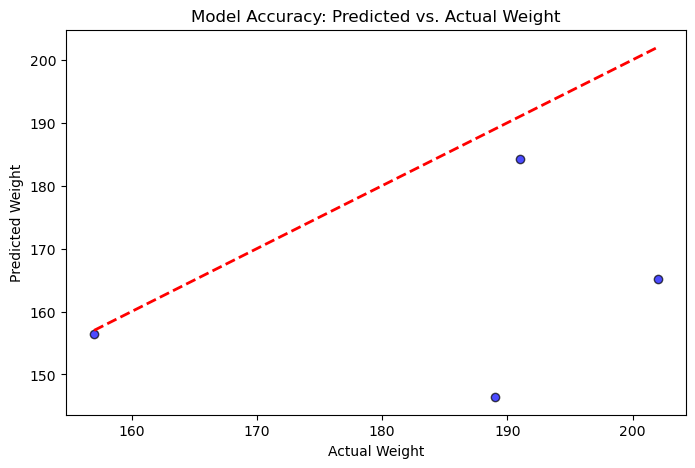

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test[:, 0], predictions[:, 0], color='blue', edgecolors='k', alpha=0.7)
plt.plot([y_test[:, 0].min(), y_test[:, 0].max()], 
         [y_test[:, 0].min(), y_test[:, 0].max()], 'r--', lw=2)
plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")
plt.title("Model Accuracy: Predicted vs. Actual Weight")
plt.show()